# WHAT IS AN ADAPTIVE LAYER IN QUANTUM NEURAL NETWORKS?
## Visualizing Dynamic Depth Architecture vs. Static Ansätze Baselines

---

### Core Insight:
* **Static Shallow ($D=2$):** Trapped at early **Underfitting** plateau (loss remains high).
* **Static Deep ($D=8$):** Paralyzed by **Barren Plateaus** where gradient variance vanishes: $\operatorname{Var}(
abla_	heta L) pprox 0$.
* **Adaptive QNN ($D(t)$ Dynamic):** Starts shallow for rapid descent, autonomously expands capacity (`ADD_LAYER`), freezes converged angles (`FREEZE`), and smoothly prunes redundant parameters (`SOFT PRUNE`).


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

os.makedirs('figures', exist_ok=True)

# ------------------------------------------------------------------------------
# 1. Telemetry Simulation: Static Shallow vs Static Deep vs Adaptive QNN
# ------------------------------------------------------------------------------
np.random.seed(42)
epochs = np.arange(0, 101)
N = len(epochs)

# Static Shallow (D = 2): Underfitting
loss_shallow = 0.38 + 0.12 * np.exp(-epochs / 6.0) + np.random.normal(0, 0.003, N)
loss_shallow[20:] = 0.38 + np.random.normal(0, 0.004, len(loss_shallow[20:]))
depth_shallow = np.full(N, 2)
grad_shallow = 0.18 * np.exp(-epochs / 15.0) + 0.04 + np.random.normal(0, 0.003, N)

# Static Deep (D = 8): Barren Plateau
loss_deep = 0.495 + np.random.normal(0, 0.005, N)
depth_deep = np.full(N, 8)
grad_deep = np.full(N, 0.001) + np.random.normal(0, 0.0002, N)

# Adaptive QNN: Dynamic D(t)
loss_adapt = np.zeros(N)
depth_adapt = np.zeros(N)
eff_depth_adapt = np.zeros(N)
grad_adapt = np.zeros(N)

# Epoch 0 - 20 (D = 1: Fast Start)
for t in range(0, 21):
    depth_adapt[t] = 1
    eff_depth_adapt[t] = 1.0
    loss_adapt[t] = 0.31 + 0.19 * np.exp(-t / 8.0) + np.random.normal(0, 0.0025)
    grad_adapt[t] = 0.22 * np.exp(-t / 15.0) + 0.05 + np.random.normal(0, 0.003)

# Epoch 21 - 45 (ADD_LAYER -> D = 2)
l20 = loss_adapt[20]
for t in range(21, 46):
    tau = t - 20
    depth_adapt[t] = 2
    eff_depth_adapt[t] = 2.0
    loss_adapt[t] = 0.16 + (l20 - 0.16) * np.exp(-tau / 7.0) + np.random.normal(0, 0.0025)
    grad_adapt[t] = 0.15 * np.exp(-tau / 12.0) + 0.04 + np.random.normal(0, 0.003)

# Epoch 46 - 65 (ADD_LAYER -> D = 3)
l45 = loss_adapt[45]
for t in range(46, 66):
    tau = t - 45
    depth_adapt[t] = 3
    eff_depth_adapt[t] = 3.0
    loss_adapt[t] = 0.065 + (l45 - 0.065) * np.exp(-tau / 7.0) + np.random.normal(0, 0.002)
    grad_adapt[t] = 0.12 * np.exp(-tau / 10.0) + 0.035 + np.random.normal(0, 0.0025)

# Epoch 66 - 80 (FREEZE Layer 1)
l65 = loss_adapt[65]
for t in range(66, 81):
    tau = t - 65
    depth_adapt[t] = 3
    eff_depth_adapt[t] = 3.0
    loss_adapt[t] = 0.042 + (l65 - 0.042) * np.exp(-tau / 6.0) + np.random.normal(0, 0.0015)
    grad_adapt[t] = 0.08 * np.exp(-tau / 8.0) + 0.03 + np.random.normal(0, 0.002)

# Epoch 81 - 100 (SOFT PRUNE Layer 3 via Cosine Soft-Mask)
l80 = loss_adapt[80]
for t in range(81, 101):
    tau = t - 80
    T_fade = 15.0
    w = 0.5 * (1.0 + np.cos(np.pi * min(tau, T_fade) / T_fade)) if tau <= T_fade else 0.0
    depth_adapt[t] = 3 if tau < T_fade else 2
    eff_depth_adapt[t] = 2.0 + w
    loss_adapt[t] = 0.033 + (l80 - 0.033) * np.exp(-tau / 10.0) + np.random.normal(0, 0.001)
    grad_adapt[t] = 0.035 + np.random.normal(0, 0.0015)

print("Telemetry data generated successfully for 100 epochs.")


Telemetry data generated successfully for 100 epochs.


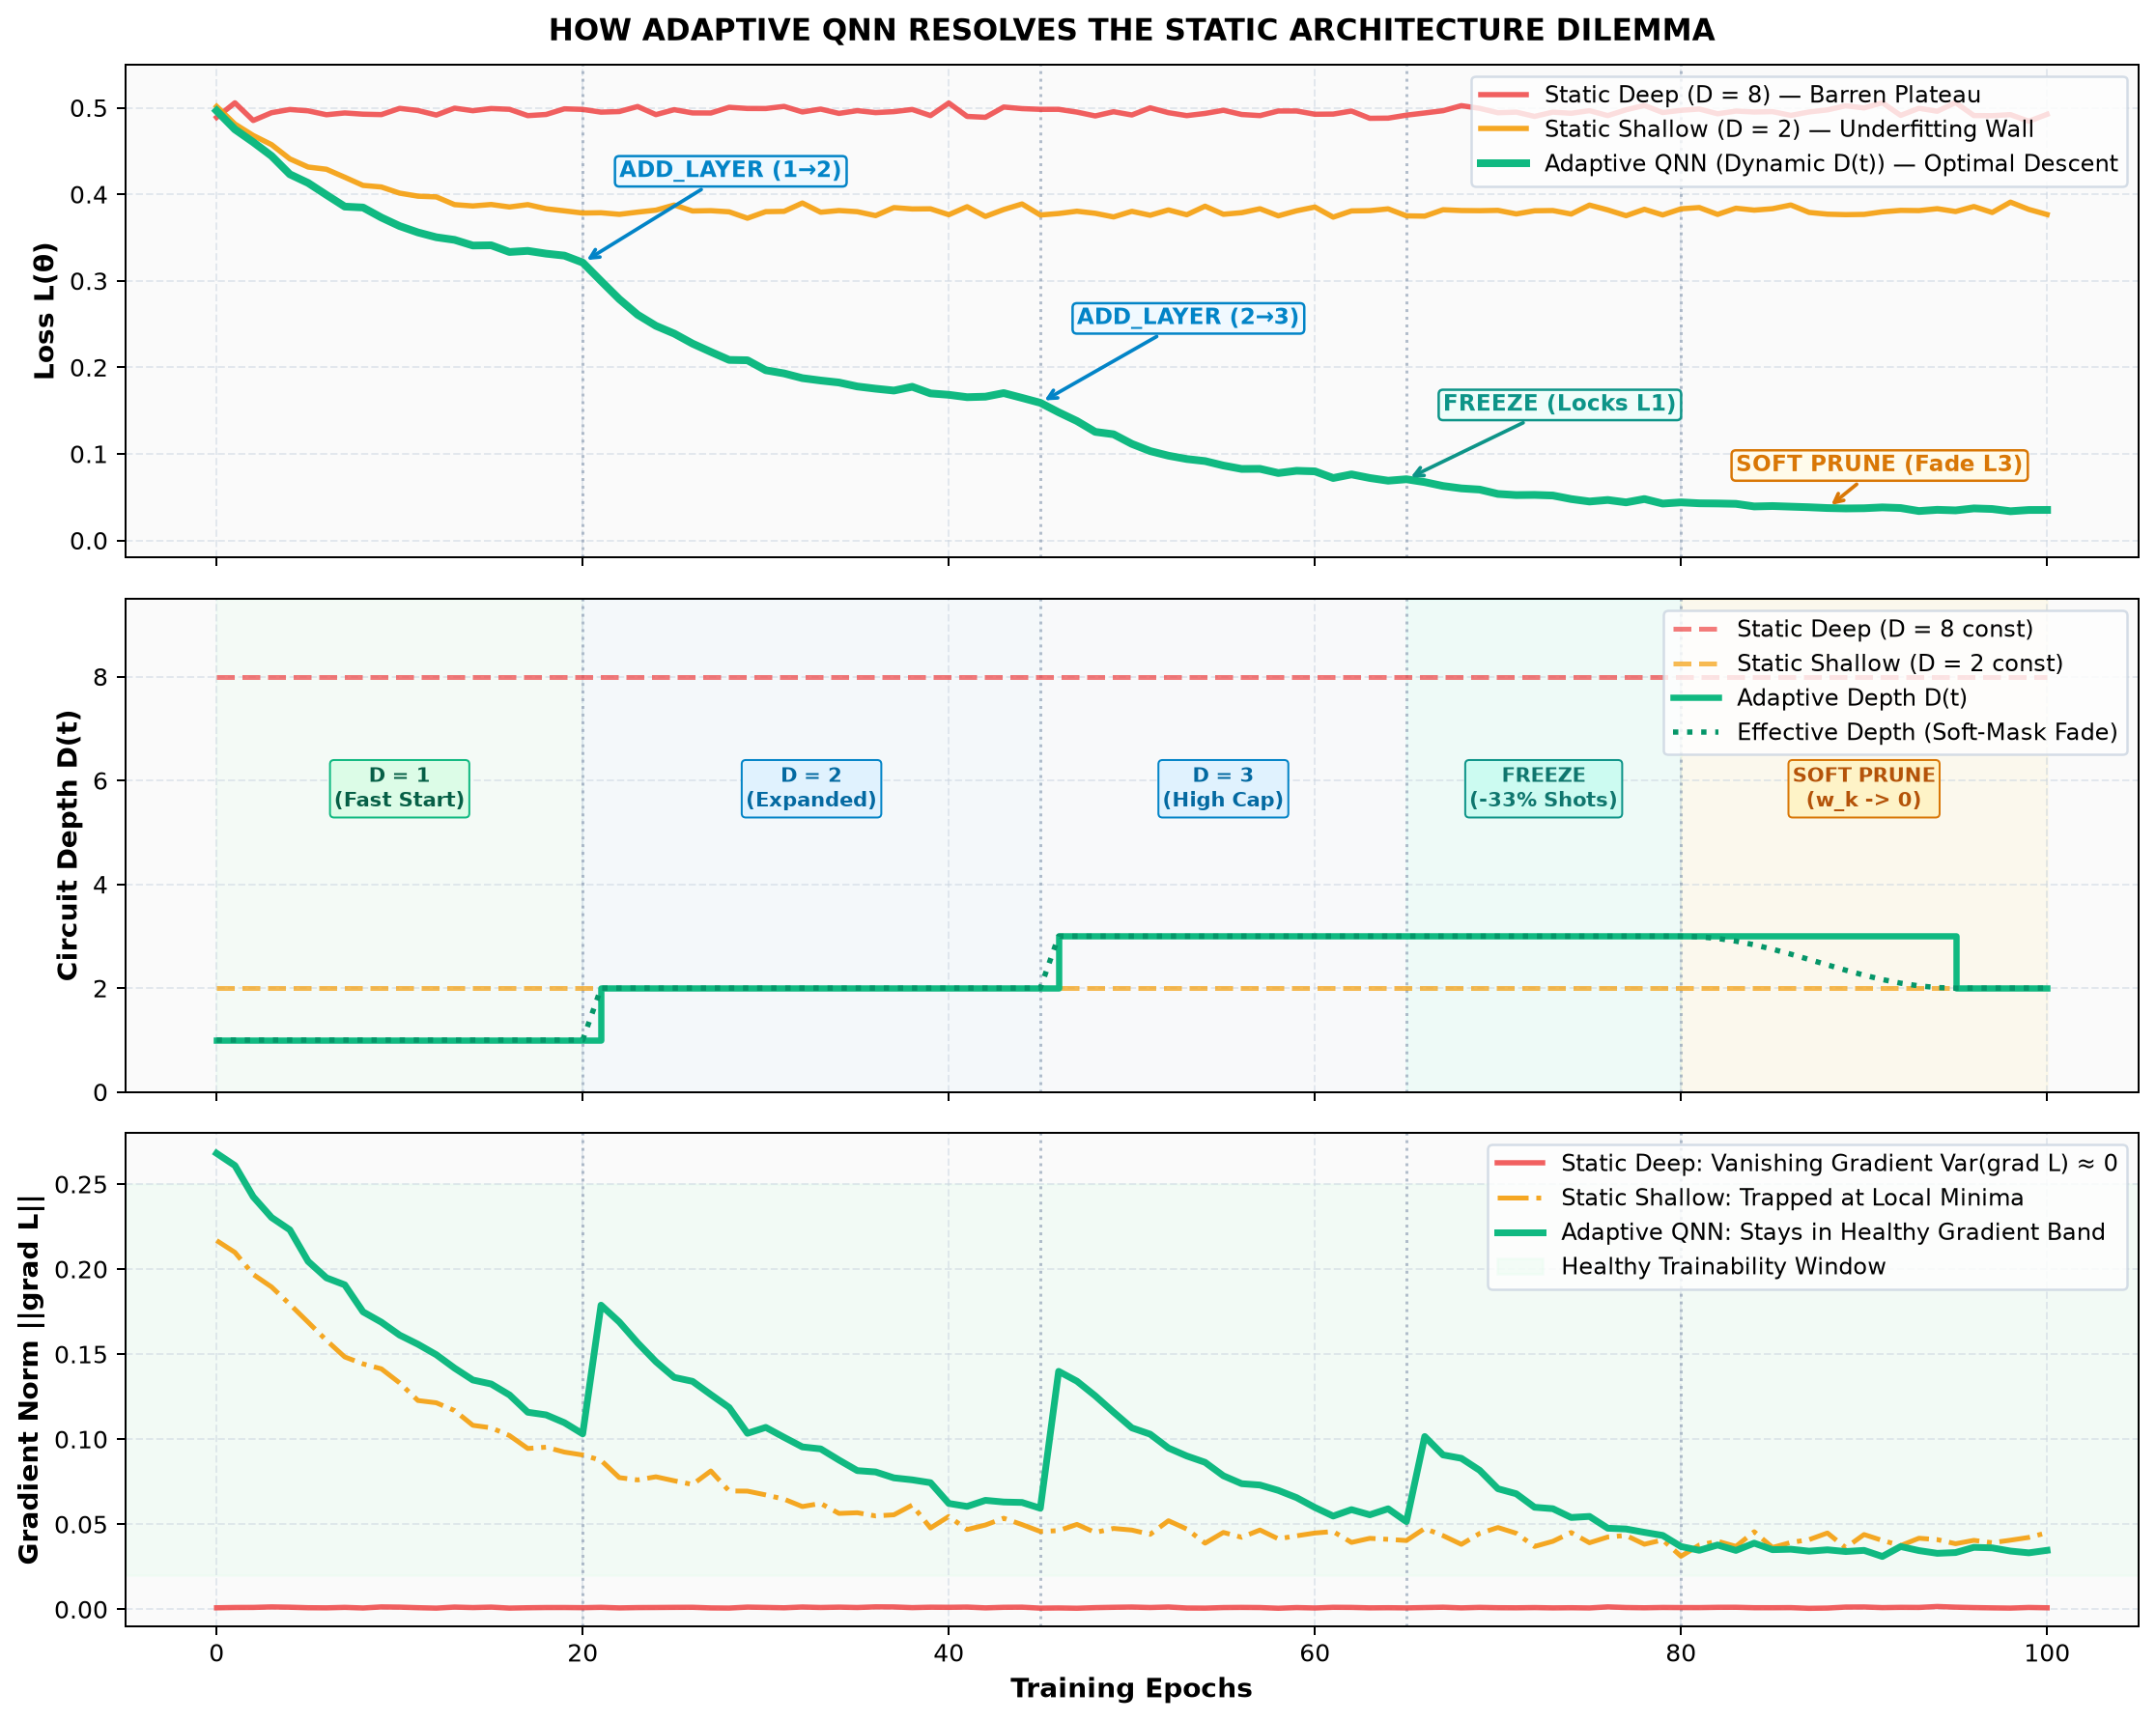

In [2]:
# ------------------------------------------------------------------------------
# 2. Publication-Grade Matplotlib Figure (Clean, Minimal Text, Data-Driven)
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12.5, 10), sharex=True, dpi=180)
fig.patch.set_facecolor('#FFFFFF')

c_deep = '#EF4444'      # Red
c_shallow = '#F59E0B'   # Amber
c_adapt = '#10B981'     # Emerald Green
c_accent = '#0284C7'    # Sky Blue

# Phase divider lines
for px in [20, 45, 65, 80]:
    for ax in (ax1, ax2, ax3):
        ax.axvline(px, color='#94A3B8', linestyle=':', lw=1.2, alpha=0.7)

# --- Subplot 1: Loss ---
ax1.plot(epochs, loss_deep, color=c_deep, lw=2.2, label='Static Deep (D = 8) — Barren Plateau', alpha=0.85)
ax1.plot(epochs, loss_shallow, color=c_shallow, lw=2.2, label='Static Shallow (D = 2) — Underfitting Wall', alpha=0.9)
ax1.plot(epochs, loss_adapt, color=c_adapt, lw=3.2, label='Adaptive QNN (Dynamic D(t)) — Optimal Descent')

ax1.annotate('ADD_LAYER (1→2)', xy=(20, loss_adapt[20]), xytext=(22, 0.42),
             arrowprops=dict(arrowstyle="->", color=c_accent, lw=1.5),
             fontsize=9, fontweight='bold', color=c_accent,
             bbox=dict(boxstyle="round,pad=0.2", fc="#F0F9FF", ec=c_accent, lw=1))
ax1.annotate('ADD_LAYER (2→3)', xy=(45, loss_adapt[45]), xytext=(47, 0.25),
             arrowprops=dict(arrowstyle="->", color=c_accent, lw=1.5),
             fontsize=9, fontweight='bold', color=c_accent,
             bbox=dict(boxstyle="round,pad=0.2", fc="#F0F9FF", ec=c_accent, lw=1))
ax1.annotate('FREEZE (Locks L1)', xy=(65, loss_adapt[65]), xytext=(67, 0.15),
             arrowprops=dict(arrowstyle="->", color='#0D9488', lw=1.5),
             fontsize=9, fontweight='bold', color='#0D9488',
             bbox=dict(boxstyle="round,pad=0.2", fc="#F0FDFA", ec='#0D9488', lw=1))
ax1.annotate('SOFT PRUNE (Fade L3)', xy=(88, loss_adapt[88]), xytext=(83, 0.08),
             arrowprops=dict(arrowstyle="->", color='#D97706', lw=1.5),
             fontsize=9, fontweight='bold', color='#D97706',
             bbox=dict(boxstyle="round,pad=0.2", fc="#FFFBEB", ec='#D97706', lw=1))

ax1.set_ylabel('Loss L(θ)', fontsize=11, fontweight='bold')
ax1.set_ylim(-0.02, 0.55)
ax1.legend(loc='upper right', frameon=True, facecolor='#FFFFFF', edgecolor='#CBD5E1', fontsize=9.5)
ax1.set_title('HOW ADAPTIVE QNN RESOLVES THE STATIC ARCHITECTURE DILEMMA', fontsize=12.5, fontweight='bold', pad=10)

# --- Subplot 2: Depth ---
ax2.plot(epochs, depth_deep, color=c_deep, lw=2, ls='--', alpha=0.7, label='Static Deep (D = 8 const)')
ax2.plot(epochs, depth_shallow, color=c_shallow, lw=2, ls='--', alpha=0.7, label='Static Shallow (D = 2 const)')
ax2.step(epochs, depth_adapt, color=c_adapt, lw=2.6, where='post', label='Adaptive Depth D(t)')
ax2.plot(epochs, eff_depth_adapt, color='#059669', lw=2.2, ls=':', label='Effective Depth (Soft-Mask Fade)')

ax2.axvspan(0, 20, color='#DCFCE7', alpha=0.2)
ax2.axvspan(20, 45, color='#E0F2FE', alpha=0.2)
ax2.axvspan(45, 65, color='#F0F9FF', alpha=0.2)
ax2.axvspan(65, 80, color='#CCFBF1', alpha=0.25)
ax2.axvspan(80, 100, color='#FEF3C7', alpha=0.25)

ax2.text(10, 5.5, "D = 1\n(Fast Start)", ha='center', fontsize=8.5, color='#065F46', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', fc='#DCFCE7', ec='#10B981', lw=0.8))
ax2.text(32.5, 5.5, "D = 2\n(Expanded)", ha='center', fontsize=8.5, color='#0369A1', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', fc='#E0F2FE', ec='#0284C7', lw=0.8))
ax2.text(55, 5.5, "D = 3\n(High Cap)", ha='center', fontsize=8.5, color='#0369A1', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', fc='#E0F2FE', ec='#0284C7', lw=0.8))
ax2.text(72.5, 5.5, "FREEZE\n(-33% Shots)", ha='center', fontsize=8.5, color='#0F766E', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', fc='#CCFBF1', ec='#0D9488', lw=0.8))
ax2.text(90, 5.5, "SOFT PRUNE\n(w_k -> 0)", ha='center', fontsize=8.5, color='#B45309', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', fc='#FEF3C7', ec='#D97706', lw=0.8))

ax2.set_ylabel('Circuit Depth D(t)', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 9.5)
ax2.legend(loc='upper right', frameon=True, facecolor='#FFFFFF', edgecolor='#CBD5E1', fontsize=9.5)

# --- Subplot 3: Gradient Norm ---
ax3.plot(epochs, grad_deep, color=c_deep, lw=2.2, label='Static Deep: Vanishing Gradient Var(grad L) ≈ 0', alpha=0.85)
ax3.plot(epochs, grad_shallow, color=c_shallow, lw=2.0, ls='-.', label='Static Shallow: Trapped at Local Minima', alpha=0.9)
ax3.plot(epochs, grad_adapt, color=c_adapt, lw=2.8, label='Adaptive QNN: Stays in Healthy Gradient Band')

ax3.axhspan(0.02, 0.25, color='#DCFCE7', alpha=0.25, label='Healthy Trainability Window')
ax3.set_ylabel('Gradient Norm ||grad L||', fontsize=11, fontweight='bold')
ax3.set_xlabel('Training Epochs', fontsize=11, fontweight='bold')
ax3.set_ylim(-0.01, 0.28)
ax3.legend(loc='upper right', frameon=True, facecolor='#FFFFFF', edgecolor='#CBD5E1', fontsize=9.5)

for ax in (ax1, ax2, ax3):
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')

plt.tight_layout()
plt.savefig('figures/fig_intro_adaptive_vs_static.png', bbox_inches='tight')
plt.show()


### Interactive Plotly Dashboard & Animated Timeline

In [3]:
# ------------------------------------------------------------------------------
# 3. Interactive Plotly Dashboard (Hover Tooltips & Synchronized Pan/Zoom)
# ------------------------------------------------------------------------------
fig_plotly = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.07,
    subplot_titles=(
        "<b>(A) Loss Convergence Trajectory L(θ)</b> — Escaping Plateaus vs. Paralyzed Baselines",
        "<b>(B) Dynamic Circuit Depth D(t)</b> — Autonomous On-Demand Architecture Evolution",
        "<b>(C) Trainability & Gradient Health ||grad L||</b> — Preserving Gradient without Barren Plateaus"
    )
)

# Row 1
fig_plotly.add_trace(go.Scatter(x=epochs, y=loss_deep, mode='lines', name='Static Deep (D=8)',
                                line=dict(color='#EF4444', width=2.2)), row=1, col=1)
fig_plotly.add_trace(go.Scatter(x=epochs, y=loss_shallow, mode='lines', name='Static Shallow (D=2)',
                                line=dict(color='#F59E0B', width=2.2)), row=1, col=1)
fig_plotly.add_trace(go.Scatter(x=epochs, y=loss_adapt, mode='lines', name='Adaptive QNN (Dynamic)',
                                line=dict(color='#10B981', width=3.2)), row=1, col=1)

fig_plotly.add_annotation(x=20, y=loss_adapt[20], text="ADD_LAYER (1→2)", showarrow=True,
                          arrowhead=2, arrowcolor="#0284C7", bgcolor="#E0F2FE", bordercolor="#0284C7", row=1, col=1)
fig_plotly.add_annotation(x=45, y=loss_adapt[45], text="ADD_LAYER (2→3)", showarrow=True,
                          arrowhead=2, arrowcolor="#0284C7", bgcolor="#E0F2FE", bordercolor="#0284C7", row=1, col=1)
fig_plotly.add_annotation(x=65, y=loss_adapt[65], text="FREEZE L1", showarrow=True,
                          arrowhead=2, arrowcolor="#0D9488", bgcolor="#CCFBF1", bordercolor="#0D9488", row=1, col=1)
fig_plotly.add_annotation(x=88, y=loss_adapt[88], text="SOFT PRUNE L3", showarrow=True,
                          arrowhead=2, arrowcolor="#D97706", bgcolor="#FEF3C7", bordercolor="#D97706", row=1, col=1)

# Row 2
fig_plotly.add_trace(go.Scatter(x=epochs, y=depth_deep, mode='lines', name='Depth: Deep (8)',
                                line=dict(color='#EF4444', width=1.8, dash='dash')), row=2, col=1)
fig_plotly.add_trace(go.Scatter(x=epochs, y=depth_shallow, mode='lines', name='Depth: Shallow (2)',
                                line=dict(color='#F59E0B', width=1.8, dash='dash')), row=2, col=1)
fig_plotly.add_trace(go.Scatter(x=epochs, y=depth_adapt, mode='lines', name='Adaptive Depth D(t)',
                                line=dict(color='#10B981', width=2.8, shape='hv')), row=2, col=1)
fig_plotly.add_trace(go.Scatter(x=epochs, y=eff_depth_adapt, mode='lines', name='Effective Soft Depth',
                                line=dict(color='#059669', width=2.0, dash='dot')), row=2, col=1)

# Row 3
fig_plotly.add_trace(go.Scatter(x=epochs, y=grad_deep, mode='lines', name='Grad: Deep (~0)',
                                line=dict(color='#EF4444', width=2)), row=3, col=1)
fig_plotly.add_trace(go.Scatter(x=epochs, y=grad_shallow, mode='lines', name='Grad: Shallow',
                                line=dict(color='#F59E0B', width=2, dash='dashdot')), row=3, col=1)
fig_plotly.add_trace(go.Scatter(x=epochs, y=grad_adapt, mode='lines', name='Grad: Adaptive',
                                line=dict(color='#10B981', width=2.8)), row=3, col=1)

fig_plotly.update_layout(
    height=800,
    template='plotly_white',
    hovermode='x unified',
    title=dict(
        text="<b>Interactive Telemetry: Static Baselines vs Adaptive Layer</b>",
        x=0.05, y=0.97
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig_plotly.update_yaxes(title_text="<b>Loss L(θ)</b>", row=1, col=1)
fig_plotly.update_yaxes(title_text="<b>Depth D(t)</b>", row=2, col=1)
fig_plotly.update_yaxes(title_text="<b>Gradient Norm</b>", row=3, col=1)
fig_plotly.update_xaxes(title_text="<b>Training Epoch</b>", row=3, col=1)

fig_plotly.write_html('figures/fig_intro_adaptive_layer_plotly.html', include_plotlyjs=True)
fig_plotly.show()


In [4]:
# ------------------------------------------------------------------------------
# 4. Animated Play/Pause Timeline Evolution (Epoch 0 -> 100)
# ------------------------------------------------------------------------------
anim_epochs = epochs[::2]
frames = []

for k, ep in enumerate(anim_epochs):
    idx = ep + 1
    frame_data = [
        # Row 1: Loss
        go.Scatter(x=epochs[:idx], y=loss_deep[:idx]),
        go.Scatter(x=epochs[:idx], y=loss_shallow[:idx]),
        go.Scatter(x=epochs[:idx], y=loss_adapt[:idx]),
        # Row 2: Depth
        go.Scatter(x=epochs[:idx], y=depth_deep[:idx]),
        go.Scatter(x=epochs[:idx], y=depth_shallow[:idx]),
        go.Scatter(x=epochs[:idx], y=depth_adapt[:idx]),
        go.Scatter(x=epochs[:idx], y=eff_depth_adapt[:idx]),
        # Row 3: Gradient
        go.Scatter(x=epochs[:idx], y=grad_deep[:idx]),
        go.Scatter(x=epochs[:idx], y=grad_shallow[:idx]),
        go.Scatter(x=epochs[:idx], y=grad_adapt[:idx])
    ]
    frames.append(go.Frame(data=frame_data, name=str(ep)))

fig_anim = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        "<b>(A) Dynamic Loss Trajectory L(t)</b>",
        "<b>(B) Adaptive Depth Evolution D(t)</b>",
        "<b>(C) Gradient Variance Window</b>"
    )
)

fig_anim.add_trace(go.Scatter(x=epochs[:1], y=loss_deep[:1], mode='lines', name='Static Deep (D=8)', line=dict(color='#EF4444', width=2)), row=1, col=1)
fig_anim.add_trace(go.Scatter(x=epochs[:1], y=loss_shallow[:1], mode='lines', name='Static Shallow (D=2)', line=dict(color='#F59E0B', width=2)), row=1, col=1)
fig_anim.add_trace(go.Scatter(x=epochs[:1], y=loss_adapt[:1], mode='lines', name='Adaptive QNN', line=dict(color='#10B981', width=3)), row=1, col=1)

fig_anim.add_trace(go.Scatter(x=epochs[:1], y=depth_deep[:1], mode='lines', name='Depth: Deep (8)', line=dict(color='#EF4444', dash='dash')), row=2, col=1)
fig_anim.add_trace(go.Scatter(x=epochs[:1], y=depth_shallow[:1], mode='lines', name='Depth: Shallow (2)', line=dict(color='#F59E0B', dash='dash')), row=2, col=1)
fig_anim.add_trace(go.Scatter(x=epochs[:1], y=depth_adapt[:1], mode='lines', name='Adaptive Depth', line=dict(color='#10B981', width=2.8, shape='hv')), row=2, col=1)
fig_anim.add_trace(go.Scatter(x=epochs[:1], y=eff_depth_adapt[:1], mode='lines', name='Effective Soft Depth', line=dict(color='#059669', dash='dot')), row=2, col=1)

fig_anim.add_trace(go.Scatter(x=epochs[:1], y=grad_deep[:1], mode='lines', name='Grad: Deep', line=dict(color='#EF4444')), row=3, col=1)
fig_anim.add_trace(go.Scatter(x=epochs[:1], y=grad_shallow[:1], mode='lines', name='Grad: Shallow', line=dict(color='#F59E0B', dash='dashdot')), row=3, col=1)
fig_anim.add_trace(go.Scatter(x=epochs[:1], y=grad_adapt[:1], mode='lines', name='Grad: Adaptive', line=dict(color='#10B981', width=2.5)), row=3, col=1)

fig_anim.frames = frames

updatemenus = [dict(
    type='buttons',
    showactive=False,
    x=0.05, y=1.12,
    buttons=[
        dict(label='▶ Play Evolution',
             method='animate',
             args=[None, dict(frame=dict(duration=80, redraw=False), fromcurrent=True, mode='immediate')]),
        dict(label='⏸ Pause',
             method='animate',
             args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    ]
)]

sliders = [dict(
    steps=[dict(method='animate',
                args=[[str(ep)], dict(mode='immediate', frame=dict(duration=0, redraw=False))],
                label=f"{ep}") for ep in anim_epochs],
    x=0.18, y=1.12, len=0.78,
    currentvalue=dict(font=dict(size=12, color='#0F172A'), prefix='Epoch: ', visible=True)
)]

fig_anim.update_layout(
    height=800,
    template='plotly_white',
    title=dict(text="<b>Animated Evolution: Watch Circuit Depth Adapt as Loss Drops</b>", x=0.05, y=0.98),
    updatemenus=updatemenus,
    sliders=sliders,
    legend=dict(orientation="h", yanchor="bottom", y=-0.12, xanchor="center", x=0.5)
)
fig_anim.update_xaxes(range=[0, 100], row=1, col=1)
fig_anim.update_xaxes(range=[0, 100], row=2, col=1)
fig_anim.update_xaxes(range=[0, 100], title_text="<b>Epochs</b>", row=3, col=1)

fig_anim.update_yaxes(range=[-0.02, 0.55], title_text="<b>Loss</b>", row=1, col=1)
fig_anim.update_yaxes(range=[0, 9], title_text="<b>Depth D(t)</b>", row=2, col=1)
fig_anim.update_yaxes(range=[-0.01, 0.28], title_text="<b>Gradient Norm</b>", row=3, col=1)

fig_anim.write_html('figures/anim_intro_adaptive_layer.html', include_plotlyjs=True)
fig_anim.show()
